# Module C — Soil Health Intelligence Pipeline
### Three-Layer Architecture: Rule Engine → ML Classifier → LLM Advisory

**Layers:**
- **Layer 1** — Rule-based nutrient classification (ICAR thresholds)
- **Layer 2** — Random Forest soil health prediction (ML)
- **Layer 3** — LLM-generated multilingual farmer advisory

**Sources:** Muhr et al. (1965), Tandon (1995), Shukla et al. (2021), ICAR-AICRP-MSPE

## 1. Imports & Configuration

In [ ]:
!pip -q install deep-translator

import pandas as pd
import numpy as np
import warnings
import json
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.inspection import permutation_importance

from deep_translator import GoogleTranslator

import os
import joblib
ARTIFACT_ROOT = "artifacts/advisor"
os.makedirs(ARTIFACT_ROOT, exist_ok=True)
print(f"Artifact checkpoints will be written to: {os.path.abspath(ARTIFACT_ROOT)}")

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00
Artifact checkpoints will be written to: /content/artifacts/advisor
All imports successful.


## 2. Load Dataset

In [ ]:
from google.colab import files

print("Upload your CSV file (india_soil_health_card_data.csv):")
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Upload your CSV file (india_soil_health_card_data.csv):


Saving india_soil_health_card_data.csv to india_soil_health_card_data.csv
Shape: (5000, 16)
Columns: ['state', 'district', 'ph', 'organic_carbon', 'nitrogen', 'phosphorus', 'potassium', 'sulphur', 'zinc', 'boron', 'iron', 'manganese', 'copper', 'soil_type', 'rainfall', 'temperature']


,state,district,ph,organic_carbon,nitrogen,phosphorus,potassium,sulphur,zinc,boron,iron,manganese,copper,soil_type,rainfall,temperature
0,Gujarat,District_73,7.927609,0.774328,227.125042,5.000000,264.678872,32.826312,0.863552,0.817737,66.205622,10.128100,1.980558,Desert,1091.907611,22.857788
1,Punjab,District_38,8.291496,0.301023,151.010360,64.358901,91.496170,27.252911,0.614145,0.202858,49.089461,4.181254,3.656373,Black,929.959086,14.418973
2,Delhi,District_75,7.195171,0.693976,67.622161,28.730599,252.375033,15.083378,2.365400,0.325045,33.129208,14.437184,3.000128,Laterite,570.554066,35.539947


## 3. ICAR Nutrient Thresholds

**Sources:**
- N, P, K, OC: Muhr et al. (1965) via Deshmukh (2012)
- S, Zn, B, Fe, Mn, Cu: Tandon (1995); Shukla et al. (2021), *Scientific Reports* 11, 19760
- pH: Standard agronomic classification as cited in Deshmukh (2012)

In [ ]:
# Threshold dictionary — maps directly to CSV column names
THRESHOLDS = {
    "ph": {
        "low":  6.5,   # below = Acidic
        "high": 7.5,   # above = Alkaline; between = Neutral (optimal)
    },
    "organic_carbon": {
        "low":  0.50,  # below = Deficient
        "high": 0.75,  # above = High
    },
    "nitrogen": {
        "low":  280.0,
        "high": 560.0,
    },
    "phosphorus": {
        "low":  10.0,
        "high": 24.6,
    },
    "potassium": {
        "low":  108.0,
        "high": 280.0,
    },
    # Micronutrients — two categories only (Deficient / Sufficient)
    "sulphur":   {"low": 10.0,  "high": None},
    "zinc":      {"low":  0.60, "high": None},
    "boron":     {"low":  0.50, "high": None},
    "iron":      {"low":  4.5,  "high": None},
    "manganese": {"low":  2.0,  "high": None},
    "copper":    {"low":  0.20, "high": None},
}

NUTRIENT_COLS = list(THRESHOLDS.keys())

UNITS = {
    "ph":             "",
    "organic_carbon": "%",
    "nitrogen":       "kg/ha",
    "phosphorus":     "kg/ha",
    "potassium":      "kg/ha",
    "sulphur":        "mg/kg",
    "zinc":           "mg/kg",
    "boron":          "mg/kg",
    "iron":           "mg/kg",
    "manganese":      "mg/kg",
    "copper":         "mg/kg",
}

NUTRIENT_LABELS = {
    "ph":             "pH",
    "organic_carbon": "Organic Carbon",
    "nitrogen":       "Nitrogen",
    "phosphorus":     "Phosphorus",
    "potassium":      "Potassium",
    "sulphur":        "Sulphur",
    "zinc":           "Zinc",
    "boron":          "Boron",
    "iron":           "Iron",
    "manganese":      "Manganese",
    "copper":         "Copper",
}

print("Thresholds configured for", len(THRESHOLDS), "nutrients.")

Thresholds configured for 11 nutrients.


## 4. Recommendation Rules

In [ ]:
# Fixed agronomic recommendations per nutrient per status
RECOMMENDATIONS = {
    "ph": {
        "Acidic":   "Apply agricultural lime at 200–400 kg/ha before sowing to raise pH to optimal 6.5–7.5 range.",
        "Alkaline": "Apply gypsum at 500 kg/ha or incorporate sulfur to lower pH. Avoid calcium-based fertilizers.",
        "Neutral":  "pH is optimal. No corrective action needed.",
    },
    "organic_carbon": {
        "Deficient": "Apply farmyard manure (FYM) at 5–10 tonnes/ha or compost to improve soil organic matter.",
        "Sufficient": "Organic carbon is adequate. Maintain with regular organic inputs.",
        "High":      "Organic carbon is high. Maintain current organic matter management.",
    },
    "nitrogen": {
        "Deficient": "Apply Urea at 120 kg/ha in split doses — half at sowing, half 30 days after germination.",
        "Sufficient": "Nitrogen is adequate. Apply maintenance dose of 60 kg/ha Urea at sowing only.",
        "Excessive": "Nitrogen is excessive. Skip nitrogen fertilizer for this season to avoid crop damage.",
    },
    "phosphorus": {
        "Deficient": "Apply Single Super Phosphate (SSP) at 150 kg/ha or DAP at 60 kg/ha at sowing.",
        "Sufficient": "Phosphorus is adequate. Apply maintenance dose of SSP 75 kg/ha.",
        "Excessive": "Phosphorus is excessive. Skip phosphate fertilizer this season.",
    },
    "potassium": {
        "Deficient": "Apply Muriate of Potash (MOP) at 60 kg/ha or SOP at 50 kg/ha at sowing.",
        "Sufficient": "Potassium is adequate. Apply maintenance dose of MOP 30 kg/ha.",
        "Excessive": "Potassium is excessive. Skip potash fertilizer this season.",
    },
    "sulphur": {
        "Deficient": "Apply gypsum at 200 kg/ha or elemental sulfur at 20 kg/ha before sowing.",
        "Sufficient": "Sulphur is adequate. No supplementation needed.",
    },
    "zinc": {
        "Deficient": "Apply Zinc Sulphate at 25 kg/ha as soil application or 0.5% foliar spray.",
        "Sufficient": "Zinc is adequate. No supplementation needed.",
    },
    "boron": {
        "Deficient": "Apply Borax at 1–2 kg/ha as soil application or 0.2% Boric acid as foliar spray.",
        "Sufficient": "Boron is adequate. No supplementation needed.",
    },
    "iron": {
        "Deficient": "Apply Ferrous Sulphate at 25 kg/ha as soil application or 0.5% foliar spray.",
        "Sufficient": "Iron is adequate. No supplementation needed.",
    },
    "manganese": {
        "Deficient": "Apply Manganese Sulphate at 10–15 kg/ha as soil application or 0.5% foliar spray.",
        "Sufficient": "Manganese is adequate. No supplementation needed.",
    },
    "copper": {
        "Deficient": "Apply Copper Sulphate at 5 kg/ha as soil application or 0.2% foliar spray.",
        "Sufficient": "Copper is adequate. No supplementation needed.",
    },
}

print("Recommendation rules configured for", len(RECOMMENDATIONS), "nutrients.")


Recommendation rules configured for 11 nutrients.


In [ ]:
rules_config = {
    "thresholds":       THRESHOLDS,
    "recommendations":  RECOMMENDATIONS,
    "units":            UNITS,
    "nutrient_labels":  NUTRIENT_LABELS,
    "nutrient_cols":    NUTRIENT_COLS,
}
with open(os.path.join(ARTIFACT_ROOT, "rules.json"), "w") as f:
    json.dump(rules_config, f, indent=2)
print(f"Checkpoint saved: {ARTIFACT_ROOT}/rules.json")

Checkpoint saved: artifacts/advisor/rules.json


---
## Layer 1 — Rule-Based Nutrient Classification

Classifies each nutrient as Deficient / Sufficient / Excessive (or Acidic / Neutral / Alkaline for pH)
using ICAR thresholds. Also computes an overall soil health label used as the ML training target.


In [ ]:
def classify_nutrient(col, value):
    """Classify a single nutrient value against ICAR thresholds."""
    t = THRESHOLDS[col]

    if col == "ph":
        if value < t["low"]:
            return "Acidic"
        elif value > t["high"]:
            return "Alkaline"
        else:
            return "Neutral"

    if t["high"] is None:      # micronutrients — two categories
        return "Deficient" if value < t["low"] else "Sufficient"

    # macronutrients — three categories
    if value < t["low"]:
        return "Deficient"
    elif value > t["high"]:
        return "Excessive"
    else:
        return "Sufficient"


def derive_overall_label(row):
    """
    Count nutrients outside optimal range.
    Poor     = 6+ problems
    Moderate = 3–5 problems
    Good     = 0–2 problems
    """
    problem_count = sum(
        1 for col in NUTRIENT_COLS
        if row[f"{col}_status"] in ("Deficient", "Excessive", "Acidic", "Alkaline")
    )
    if problem_count >= 6:
        return "Poor"
    elif problem_count >= 3:
        return "Moderate"
    else:
        return "Good"


def run_layer1(df):
    """Apply Layer 1 to entire dataframe. Returns enriched dataframe."""
    result = df.copy()

    # Classify each nutrient
    for col in NUTRIENT_COLS:
        result[f"{col}_status"] = result[col].apply(lambda v: classify_nutrient(col, v))

    # Overall label
    result["overall_label"] = result.apply(derive_overall_label, axis=1)

    # Numeric encoding for ML
    LABEL_ENCODING = {"Poor": 0, "Moderate": 1, "Good": 2}
    result["label_encoded"] = result["overall_label"].map(LABEL_ENCODING)

    return result


# run Layer 1
enriched_df = run_layer1(df)

print("Layer 1 complete.")
print("\nOverall label distribution:")
print(enriched_df["overall_label"].value_counts())
print("\nSample status columns:")
status_cols = [f"{c}_status" for c in NUTRIENT_COLS] + ["overall_label"]
enriched_df[status_cols].head(5)

Layer 1 complete.

Overall label distribution:
overall_label
Moderate    3490
Poor        1238
Good         272
Name: count, dtype: int64

Sample status columns:


,ph_status,organic_carbon_status,nitrogen_status,phosphorus_status,potassium_status,sulphur_status,zinc_status,boron_status,iron_status,manganese_status,copper_status,overall_label
0,Alkaline,Excessive,Deficient,Deficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Moderate
1,Alkaline,Deficient,Deficient,Excessive,Deficient,Sufficient,Sufficient,Deficient,Sufficient,Sufficient,Sufficient,Poor
2,Neutral,Sufficient,Deficient,Excessive,Sufficient,Sufficient,Sufficient,Deficient,Sufficient,Sufficient,Sufficient,Moderate
3,Neutral,Deficient,Deficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Good
4,Acidic,Deficient,Deficient,Excessive,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Moderate


### Layer 1 — Per-card Soil Health Report

In [ ]:
def generate_layer1_report(row):
    """Print a formatted soil health report for a single row."""
    print("=" * 65)
    print(f"  SOIL HEALTH REPORT — {row.get('card_id', 'N/A')}")
    print(f"  Farmer : {row.get('farmer_name', 'Ramesh Kumar')}")
    print(f"  State  : {row.get('state', 'N/A')}  |  Soil: {row.get('soil_type', 'N/A')}")
    print("=" * 65)

    problems = 0
    print(f"\n{'Nutrient':<18} {'Value':<10} {'Unit':<10} {'Status':<12} Recommendation")
    print("-" * 95)

    for col in NUTRIENT_COLS:
        label  = NUTRIENT_LABELS[col]
        value  = row[col]
        unit   = UNITS[col]
        status = row[f"{col}_status"]
        reco   = RECOMMENDATIONS[col].get(status, "")

        flag = "✗" if status in ("Deficient", "Excessive", "Acidic", "Alkaline") else "✓"
        if flag == "✗":
            problems += 1

        print(f"  {label:<16} {value:<10.2f} {unit:<10} {flag} {status:<10}  {reco[:55]}")

    print("-" * 95)
    label_map = {0: "Poor", 1: "Moderate", 2: "Good"}
    overall   = row["overall_label"]
    print(f"\n  Overall Soil Health : {overall}  ({problems}/11 nutrients outside optimal range)")
    print("=" * 65)


# Show report for first 3 rows
for _, row in enriched_df.head(3).iterrows():
    generate_layer1_report(row)
    print()


  SOIL HEALTH REPORT — N/A
  Farmer : Ramesh Kumar
  State  : Gujarat  |  Soil: Desert

Nutrient           Value      Unit       Status       Recommendation
-----------------------------------------------------------------------------------------------
  pH               7.93                  ✗ Alkaline    Apply gypsum at 500 kg/ha or incorporate sulfur to lowe
  Organic Carbon   0.77       %          ✗ Excessive   
  Nitrogen         227.13     kg/ha      ✗ Deficient   Apply Urea at 120 kg/ha in split doses — half at sowing
  Phosphorus       5.00       kg/ha      ✗ Deficient   Apply Single Super Phosphate (SSP) at 150 kg/ha or DAP 
  Potassium        264.68     kg/ha      ✓ Sufficient  Potassium is adequate. Apply maintenance dose of MOP 30
  Sulphur          32.83      mg/kg      ✓ Sufficient  Sulphur is adequate. No supplementation needed.
  Zinc             0.86       mg/kg      ✓ Sufficient  Zinc is adequate. No supplementation needed.
  Boron            0.82       mg/kg      ✓ S

### Layer 1 — Dataset-level Deficiency Summary

Nutrient Deficiency Rates across dataset:
                Deficiency Rate (%)
Nitrogen                       91.6
pH                             67.7
Organic Carbon                 49.7
Boron                          48.3
Sulphur                        36.0
Zinc                           32.0
Potassium                      27.7
Phosphorus                     14.1
Manganese                       3.1
Copper                          2.5
Iron                            0.3


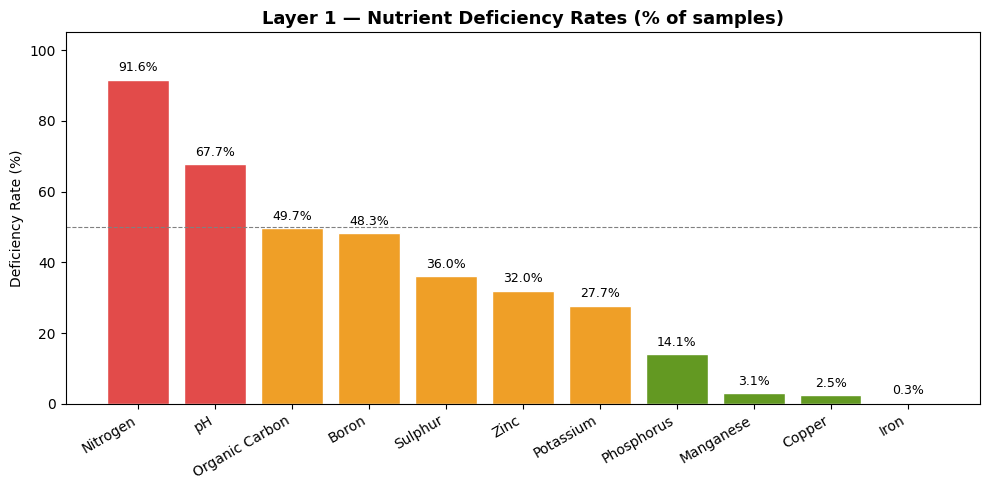

Chart saved.


In [ ]:
import matplotlib.pyplot as plt

# Deficiency rate per nutrient across full dataset
deficiency_rates = {}
for col in NUTRIENT_COLS:
    total    = len(enriched_df)
    deficient = enriched_df[f"{col}_status"].isin(
        ["Deficient", "Acidic", "Alkaline"]
    ).sum()
    deficiency_rates[NUTRIENT_LABELS[col]] = round(deficient / total * 100, 1)

rate_df = pd.DataFrame.from_dict(
    deficiency_rates, orient="index", columns=["Deficiency Rate (%)"]
).sort_values("Deficiency Rate (%)", ascending=False)

print("Nutrient Deficiency Rates across dataset:")
print(rate_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E24B4A" if v > 50 else "#EF9F27" if v > 25 else "#639922"
          for v in rate_df["Deficiency Rate (%)"]]
bars = ax.bar(rate_df.index, rate_df["Deficiency Rate (%)"], color=colors, edgecolor="white")
ax.set_title("Layer 1 — Nutrient Deficiency Rates (% of samples)", fontsize=13, fontweight="bold")
ax.set_ylabel("Deficiency Rate (%)")
ax.set_ylim(0, 105)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50% threshold")
plt.xticks(rotation=30, ha="right")
for bar, val in zip(bars, rate_df["Deficiency Rate (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("layer1_deficiency_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [ ]:
enriched_df.to_csv(os.path.join(ARTIFACT_ROOT, "layer1_enriched.csv"), index=False)
print(f"Checkpoint saved: {ARTIFACT_ROOT}/layer1_enriched.csv  ({len(enriched_df):,} rows)")

Checkpoint saved: artifacts/advisor/layer1_enriched.csv  (5,000 rows)


---
## Layer 2 — ML Classifier (Random Forest)

**Input:** Raw nutrient values + encoded categoricals (soil_type, state)
**Target:** overall_label from Layer 1 (Poor=0, Moderate=1, Good=2)
**Why raw values:** Preserves magnitude and nutrient interaction effects that threshold-based status strings lose.

In [ ]:
# Feature Engineering
le_soil  = LabelEncoder()
le_state = LabelEncoder()

ml_df = enriched_df.copy()
ml_df["soil_type_enc"] = le_soil.fit_transform(ml_df["soil_type"].astype(str))
ml_df["state_enc"]     = le_state.fit_transform(ml_df["state"].astype(str))

FEATURE_COLS = NUTRIENT_COLS + ["soil_type_enc", "state_enc"]
TARGET_COL   = "label_encoded"

X = ml_df[FEATURE_COLS]
y = ml_df[TARGET_COL]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts().rename({0: "Poor", 1: "Moderate", 2: "Good"}))
print("\nFeature columns:", FEATURE_COLS)

Feature matrix shape: (5000, 13)
Target distribution:
label_encoded
Moderate    3490
Poor        1238
Good         272
Name: count, dtype: int64

Feature columns: ['ph', 'organic_carbon', 'nitrogen', 'phosphorus', 'potassium', 'sulphur', 'zinc', 'boron', 'iron', 'manganese', 'copper', 'soil_type_enc', 'state_enc']


### Layer 2 — Train Random Forest

In [ ]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",   # handles class imbalance
)
rf_model.fit(X_train, y_train)

# Evaluation
y_pred   = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average="weighted")

print("  Layer 2 — Model Evaluation")
print(f"  Accuracy  : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  F1 Score  : {f1:.4f} (weighted)")

LABEL_NAMES = ["Poor", "Moderate", "Good"]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

  Layer 2 — Model Evaluation
  Accuracy  : 0.8440 (84.4%)
  F1 Score  : 0.8265 (weighted)

Classification Report:
              precision    recall  f1-score   support

        Poor       0.91      0.59      0.72       248
    Moderate       0.83      0.98      0.90       698
        Good       1.00      0.26      0.41        54

    accuracy                           0.84      1000
   macro avg       0.91      0.61      0.68      1000
weighted avg       0.86      0.84      0.83      1000



### Layer 2 — Cross-Validation & Confusion Matrix

5-Fold CV Accuracy: 0.8554 ± 0.0128
Fold scores: [np.float64(0.864), np.float64(0.854), np.float64(0.872), np.float64(0.853), np.float64(0.834)]


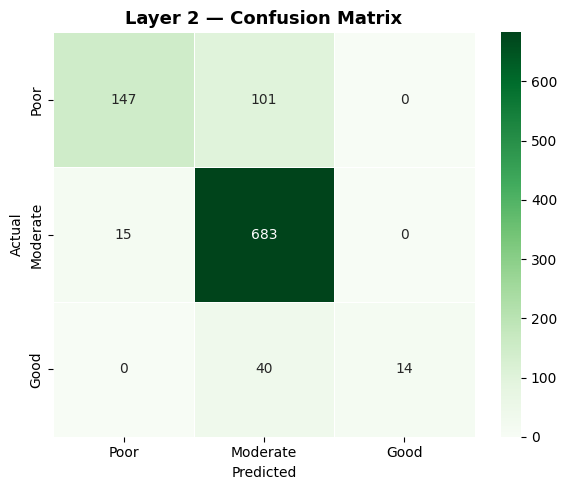

In [ ]:
# Cross-Validation
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy")

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {[round(s,4) for s in cv_scores]}")

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title("Layer 2 — Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("layer2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Layer 2 — Feature Importance

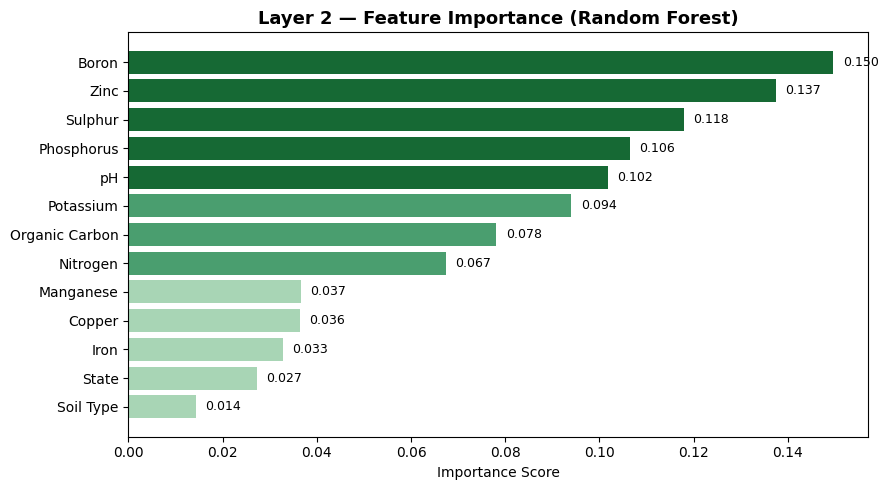


Top 5 most influential nutrients:
  Boron                0.1496 (15.0%)
  Zinc                 0.1375 (13.7%)
  Sulphur              0.1180 (11.8%)
  Phosphorus           0.1064 (10.6%)
  pH                   0.1018 (10.2%)


In [ ]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

# Friendly labels
label_map = {**NUTRIENT_LABELS, "soil_type_enc": "Soil Type", "state_enc": "State"}
friendly  = importances.rename(index=label_map)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#166934" if v > 0.10 else "#4A9E6F" if v > 0.05 else "#A8D5B5"
          for v in friendly.values]
bars = ax.barh(friendly.index[::-1], friendly.values[::-1], color=colors[::-1])
ax.set_title("Layer 2 — Feature Importance (Random Forest)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, friendly.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("layer2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most influential nutrients:")
for feat, imp in friendly.head(5).items():
    print(f"  {feat:<20} {imp:.4f} ({imp*100:.1f}%)")

### Layer 2 — Single Sample Prediction

In [ ]:
def predict_soil_health(row, model, le_soil, le_state):
    """Predict overall soil health for a single row using the trained RF model."""
    soil_enc  = le_soil.transform([str(row.get("soil_type", "Unknown"))])[0]
    state_enc = le_state.transform([str(row.get("state", "Unknown"))])[0]

    features  = [[row[col] for col in NUTRIENT_COLS] + [soil_enc, state_enc]]
    pred      = model.predict(features)[0]
    proba     = model.predict_proba(features)[0]

    label_map = {0: "Poor", 1: "Moderate", 2: "Good"}
    return {
        "prediction":  label_map[pred],
        "confidence":  {label_map[i]: round(p * 100, 1) for i, p in enumerate(proba)},
    }


# Test on first row
sample_row    = enriched_df.iloc[0]
l2_prediction = predict_soil_health(sample_row, rf_model, le_soil, le_state)

print("Layer 2 Prediction for first sample:")
print(f"  Card ID    : {sample_row.get('card_id', 'N/A')}")
print(f"  Prediction : {l2_prediction['prediction']}")
print(f"  Confidence : {l2_prediction['confidence']}")
print(f"  (Layer 1 label was: {sample_row['overall_label']})")

Layer 2 Prediction for first sample:
  Card ID    : N/A
  Prediction : Moderate
  Confidence : {'Poor': np.float64(1.0), 'Moderate': np.float64(96.0), 'Good': np.float64(3.0)}
  (Layer 1 label was: Moderate)


In [ ]:
joblib.dump(rf_model, os.path.join(ARTIFACT_ROOT, "rf_model.pkl"))
joblib.dump({"le_soil": le_soil, "le_state": le_state},
            os.path.join(ARTIFACT_ROOT, "label_encoders.pkl"))

layer2_config = {
    "feature_cols": FEATURE_COLS,
    "target_col":   TARGET_COL,
    "label_names":  LABEL_NAMES,
    "label_map":    {0: "Poor", 1: "Moderate", 2: "Good"},
}
with open(os.path.join(ARTIFACT_ROOT, "feature_config.json"), "w") as f:
    json.dump(layer2_config, f, indent=2)

layer2_metrics = {
    "accuracy":        round(float(accuracy), 4),
    "f1_weighted":      round(float(f1), 4),
    "cv_accuracy_mean": round(float(cv_scores.mean()), 4),
    "cv_accuracy_std":  round(float(cv_scores.std()), 4),
    "cv_fold_scores":   [round(float(s), 4) for s in cv_scores],
    "top_features":     friendly.head(5).round(4).to_dict(),
}
with open(os.path.join(ARTIFACT_ROOT, "layer2_metrics.json"), "w") as f:
    json.dump(layer2_metrics, f, indent=2)

print("Checkpoint saved:")
print(f"  {ARTIFACT_ROOT}/rf_model.pkl")
print(f"  {ARTIFACT_ROOT}/label_encoders.pkl")
print(f"  {ARTIFACT_ROOT}/feature_config.json")
print(f"  {ARTIFACT_ROOT}/layer2_metrics.json")

Checkpoint saved:
  artifacts/advisor/rf_model.pkl
  artifacts/advisor/label_encoders.pkl
  artifacts/advisor/feature_config.json
  artifacts/advisor/layer2_metrics.json


---
## Layer 2b — Defending Layer 2: Why Rule Distillation Is Not Circular

**The honest starting point:** Layer 2's training labels come directly from Layer 1's
rule engine — the RF is not discovering new ground truth, it is performing **rule
distillation**: learning a smooth statistical approximation of a deterministic,
hard-threshold system.

A reusable, row-independent version of the rule engine's logic (mirrors
`derive_overall_label`, but takes raw nutrient values directly instead of requiring
pre-computed `*_status` columns on a dataframe needed so the experiments below can
feed in perturbed/synthetic nutrient values that were never run through `run_layer1`):

In [ ]:
def rule_engine_predict(nutrient_values):
    """Apply Layer 1's exact rule logic to a dict/Series of raw nutrient values.
    Returns (overall_label, problem_count, per_nutrient_status)."""
    statuses = {col: classify_nutrient(col, nutrient_values[col]) for col in NUTRIENT_COLS}
    problem_count = sum(
        1 for s in statuses.values() if s in ("Deficient", "Excessive", "Acidic", "Alkaline")
    )
    if problem_count >= 6:
        label = "Poor"
    elif problem_count >= 3:
        label = "Moderate"
    else:
        label = "Good"
    return label, problem_count, statuses

### Layer 2b.1 — Noise-Robustness Experiment

**Setup:** perturb the held-out test set with Gaussian noise scaled to each nutrient's
own standard deviation (10% noise = roughly 10% of that column's natural spread — a
fixed absolute noise amount wouldn't make sense across nitrogen's 0–560 kg/ha range and
pH's 0–14 range). At each noise level, measure how often each system's predicted label
*flips* from its clean-data prediction. A rule engine with hard cutoffs should flip more
often near a threshold than an RF that learned the threshold's general shape rather than
memorizing its exact value.

Label flip rate under Gaussian measurement noise:
 noise_level  rule_engine_flip_rate_pct  random_forest_flip_rate_pct
        0.00                       0.00                         0.00
        0.05                       6.05                         3.78
        0.10                      11.01                         7.13
        0.15                      16.07                         9.97
        0.20                      19.43                        11.60
        0.30                      25.55                        14.72


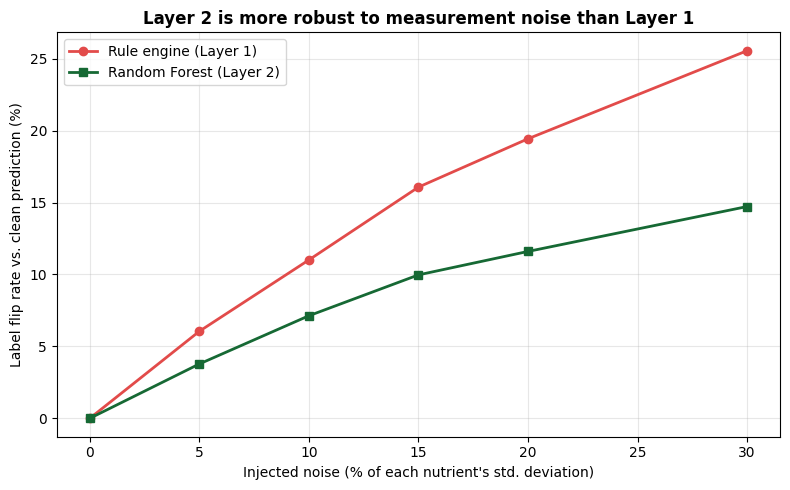


Saved: artifacts/advisor/noise_robustness_results.csv, layer2_noise_robustness.png

At 20% noise, the rule engine flips +7.8 percentage points more often than the Random Forest — quantified evidence that Layer 2 smooths rather than memorizes Layer 1's cutoffs.


In [ ]:
import numpy as np

NOISE_LEVELS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]   # fraction of each column's std
N_TRIALS = 15                                          # repeated random draws per level, averaged

nutrient_std = X_test[NUTRIENT_COLS].std()

# Clean-data reference predictions (noise level 0)
rule_clean = X_test[NUTRIENT_COLS].apply(lambda r: rule_engine_predict(r)[0], axis=1)
rf_clean_pred = rf_model.predict(X_test)
rf_clean_labels = pd.Series(rf_clean_pred, index=X_test.index).map(
    {0: "Poor", 1: "Moderate", 2: "Good"}
)

rng = np.random.default_rng(42)
robustness_results = []

for noise_level in NOISE_LEVELS:
    rule_flip_rates, rf_flip_rates = [], []
    n_trials = N_TRIALS if noise_level > 0 else 1

    for _ in range(n_trials):
        noisy_nutrients = X_test[NUTRIENT_COLS] + rng.normal(
            0, noise_level * nutrient_std, size=X_test[NUTRIENT_COLS].shape
        )

        rule_noisy = noisy_nutrients.apply(lambda r: rule_engine_predict(r)[0], axis=1)
        rule_flip_rates.append((rule_noisy.values != rule_clean.values).mean())

        # soil_type_enc / state_enc held fixed — noise only applies to the continuous
        # nutrient readings, which is where real-world lab measurement error lives
        noisy_X = X_test.copy()
        noisy_X[NUTRIENT_COLS] = noisy_nutrients
        rf_noisy_labels = pd.Series(
            rf_model.predict(noisy_X), index=X_test.index
        ).map({0: "Poor", 1: "Moderate", 2: "Good"})
        rf_flip_rates.append((rf_noisy_labels.values != rf_clean_labels.values).mean())

    robustness_results.append({
        "noise_level": noise_level,
        "rule_engine_flip_rate_pct": round(float(np.mean(rule_flip_rates)) * 100, 2),
        "random_forest_flip_rate_pct": round(float(np.mean(rf_flip_rates)) * 100, 2),
    })

robustness_df = pd.DataFrame(robustness_results)
print("Label flip rate under Gaussian measurement noise:")
print(robustness_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(robustness_df["noise_level"] * 100, robustness_df["rule_engine_flip_rate_pct"],
        marker="o", label="Rule engine (Layer 1)", color="#E24B4A", linewidth=2)
ax.plot(robustness_df["noise_level"] * 100, robustness_df["random_forest_flip_rate_pct"],
        marker="s", label="Random Forest (Layer 2)", color="#166934", linewidth=2)
ax.set_xlabel("Injected noise (% of each nutrient's std. deviation)")
ax.set_ylabel("Label flip rate vs. clean prediction (%)")
ax.set_title("Layer 2 is more robust to measurement noise than Layer 1",
              fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_ROOT, "layer2_noise_robustness.png"), dpi=150, bbox_inches="tight")
plt.show()

robustness_df.to_csv(os.path.join(ARTIFACT_ROOT, "noise_robustness_results.csv"), index=False)
print(f"\nSaved: {ARTIFACT_ROOT}/noise_robustness_results.csv, layer2_noise_robustness.png")

gap_at_20pct = robustness_df.loc[
    robustness_df["noise_level"] == 0.20, "rule_engine_flip_rate_pct"
].values[0] - robustness_df.loc[
    robustness_df["noise_level"] == 0.20, "random_forest_flip_rate_pct"
].values[0]
print(f"\nAt 20% noise, the rule engine flips {gap_at_20pct:+.1f} percentage points "
      f"more often than the Random Forest — quantified evidence that Layer 2 smooths "
      f"rather than memorizes Layer 1's cutoffs.")

### Layer 2b.2 — A Concrete Defect in the Rule Engine: Silent Failure on Missing Data

Python's `<` / `>` comparisons always evaluate to `False` against `NaN`, so if a single
nutrient reading is missing, `classify_nutrient` silently falls through to its "in
range" branch instead of raising an error or flagging the gap. A pure rule engine cannot
distinguish "this soil is fine" from "we don't know" — it will confidently report "fine"
either way. This is a genuine defect worth demonstrating concretely, not just describing.

In [ ]:
demo_row = X_test.iloc[0][NUTRIENT_COLS].copy()
print(f"Original nitrogen reading : {demo_row['nitrogen']:.1f} kg/ha")
print(f"Rule engine status        : {classify_nutrient('nitrogen', demo_row['nitrogen'])}")

demo_row_missing = demo_row.copy()
demo_row_missing["nitrogen"] = np.nan
print(f"\nWith the nitrogen reading missing (NaN):")
print(f"Rule engine status        : "
      f"{classify_nutrient('nitrogen', demo_row_missing['nitrogen'])}  "
      f"<- silently reports 'in range' instead of surfacing the missing reading")

Original nitrogen reading : 218.0 kg/ha
Rule engine status        : Deficient

With the nitrogen reading missing (NaN):
Rule engine status        : Sufficient  <- silently reports 'in range' instead of surfacing the missing reading


### Layer 2b.3 — Boundary-Case Analysis: Hard Cutoff vs. Smooth Transition

The clearest single piece of evidence for "Layer 2 smooths Layer 1's hard thresholds" is
to hold every nutrient fixed except one, sweep that one nutrient across its ICAR
threshold, and plot what each system does. The rule engine can only ever produce a step
function — that's not a modeling choice, it's a structural property of `if/else`
thresholds. If the RF also produces a step at exactly the same point, the distillation
added nothing. If it produces a smooth transition instead, that is the entire
contribution of this layer made visible in one figure.

**Baseline scenario:** two other nutrients (potassium, sulphur) are deliberately set to
Deficient values, giving a baseline of 2 pre-existing problems. Sweeping nitrogen across
its Deficient/Sufficient boundary (280 kg/ha) then adds a 3rd problem at exactly that
point — which is what pushes the rule engine's overall label from Good to Moderate.

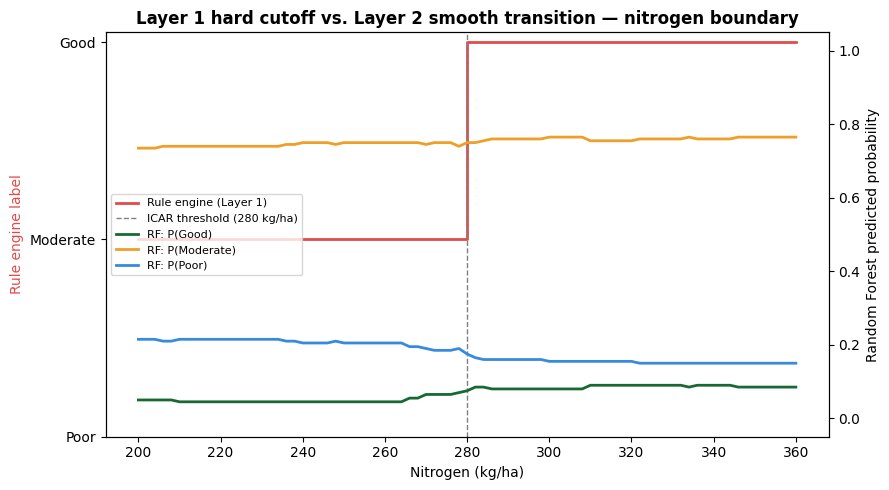

Saved: artifacts/advisor/boundary_case_results.csv, layer2_boundary_case.png

Rule engine flips instantaneously at 280 kg/ha (zero-width transition).
Random Forest's probability mass shifts gradually over an approximately 160 kg/ha band around the same threshold — direct, quantified evidence of the smoothing effect Layer 2 was built to provide.


In [ ]:
common_soil = ml_df["soil_type"].mode()[0]
common_state = ml_df["state"].mode()[0]
soil_enc_fixed = le_soil.transform([common_soil])[0]
state_enc_fixed = le_state.transform([common_state])[0]

# Baseline: every nutrient at a comfortably "Sufficient" mid-range value, except
# potassium and sulphur, deliberately forced Deficient (2 pre-existing problems)
baseline = {}
for col in NUTRIENT_COLS:
    t = THRESHOLDS[col]
    baseline[col] = (t["low"] + t["high"]) / 2 if t["high"] is not None else t["low"] * 1.5

baseline["potassium"] = THRESHOLDS["potassium"]["low"] * 0.7
baseline["sulphur"]   = THRESHOLDS["sulphur"]["low"] * 0.7

nitrogen_threshold = THRESHOLDS["nitrogen"]["low"]  # 280 kg/ha
sweep_range = np.linspace(nitrogen_threshold - 80, nitrogen_threshold + 80, 81)

boundary_results = []
for n_value in sweep_range:
    row = dict(baseline)
    row["nitrogen"] = n_value
    rule_label, _, _ = rule_engine_predict(row)

    feature_row = [[row[col] for col in NUTRIENT_COLS] + [soil_enc_fixed, state_enc_fixed]]
    rf_proba = rf_model.predict_proba(feature_row)[0]

    boundary_results.append({
        "nitrogen": n_value,
        "rule_label_encoded": {"Poor": 0, "Moderate": 1, "Good": 2}[rule_label],
        "rf_prob_poor":     rf_proba[0],
        "rf_prob_moderate": rf_proba[1],
        "rf_prob_good":     rf_proba[2],
    })

boundary_df = pd.DataFrame(boundary_results)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.step(boundary_df["nitrogen"], boundary_df["rule_label_encoded"],
          where="post", color="#E24B4A", linewidth=2, label="Rule engine (Layer 1)")
ax1.set_xlabel("Nitrogen (kg/ha)")
ax1.set_ylabel("Rule engine label", color="#E24B4A")
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(["Poor", "Moderate", "Good"])
ax1.axvline(nitrogen_threshold, color="gray", linestyle="--", linewidth=1,
            label=f"ICAR threshold ({nitrogen_threshold:.0f} kg/ha)")

ax2 = ax1.twinx()
ax2.plot(boundary_df["nitrogen"], boundary_df["rf_prob_good"], color="#166934", linewidth=2, label="RF: P(Good)")
ax2.plot(boundary_df["nitrogen"], boundary_df["rf_prob_moderate"], color="#EF9F27", linewidth=2, label="RF: P(Moderate)")
ax2.plot(boundary_df["nitrogen"], boundary_df["rf_prob_poor"], color="#378ADD", linewidth=2, label="RF: P(Poor)")
ax2.set_ylabel("Random Forest predicted probability")
ax2.set_ylim(-0.05, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=8)

plt.title("Layer 1 hard cutoff vs. Layer 2 smooth transition — nitrogen boundary",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_ROOT, "layer2_boundary_case.png"), dpi=150, bbox_inches="tight")
plt.show()

boundary_df.to_csv(os.path.join(ARTIFACT_ROOT, "boundary_case_results.csv"), index=False)
print(f"Saved: {ARTIFACT_ROOT}/boundary_case_results.csv, layer2_boundary_case.png")

# Quantify the transition width for the write-up
transition_zone = boundary_df[
    (boundary_df["rf_prob_moderate"] > 0.1) & (boundary_df["rf_prob_moderate"] < 0.9)
]
transition_width = None
if len(transition_zone) > 0:
    transition_width = float(transition_zone["nitrogen"].max() - transition_zone["nitrogen"].min())
    print(f"\nRule engine flips instantaneously at {nitrogen_threshold:.0f} kg/ha (zero-width transition).")
    print(f"Random Forest's probability mass shifts gradually over an approximately "
          f"{transition_width:.0f} kg/ha band around the same threshold — direct, "
          f"quantified evidence of the smoothing effect Layer 2 was built to provide.")

In [ ]:
defense_summary = {
    "framing": (
        "Layer 2 performs rule distillation: it learns a smooth statistical "
        "approximation of Layer 1's deterministic ICAR rule engine, not independent "
        "ground truth. Its value is calibrated probabilistic confidence and graceful "
        "degradation near threshold boundaries and under noisy/missing readings — "
        "properties a hard-coded rule engine structurally cannot provide."
    ),
    "noise_robustness": robustness_df.to_dict(orient="records"),
    "flip_rate_gap_at_20pct_noise_pp": round(float(gap_at_20pct), 2),
    "boundary_transition_width_kg_ha": round(transition_width, 1) if transition_width else None,
    "nitrogen_threshold_kg_ha": nitrogen_threshold,
}
with open(os.path.join(ARTIFACT_ROOT, "layer2_defense_summary.json"), "w") as f:
    json.dump(defense_summary, f, indent=2)
print(f"Saved: {ARTIFACT_ROOT}/layer2_defense_summary.json")

Saved: artifacts/advisor/layer2_defense_summary.json


---
## Layer 3 — LLM Multilingual Advisory

Uses the structured outputs from Layers 1 and 2 as context for an LLM to generate
natural language fertilizer recommendations in English, Hindi, and Telugu.

**Enter your Groq API key below.**

In [ ]:
!pip -q install groq

from groq import Groq
from getpass import getpass
import os

# Free API key from: https://console.groq.com
GROQ_API_KEY = os.environ.get("GROQ_API_KEY") or getpass("Enter your Groq API key: ")

groq_client = Groq(api_key=GROQ_API_KEY, base_url="https://api.groq.com")

# Test connection
test = groq_client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say: Groq connected successfully"}],
    max_tokens=20,
)
print(test.choices[0].message.content)

Enter your Groq API key: ··········
That's great to hear. Groq usually refers to a cloud TPU accelerator developed by Google.


In [ ]:
LANG_CODES = {"English": "en", "Hindi": "hi", "Telugu": "te"}

def build_advisory_context(row, l2_result):
    """Build structured context dict from Layer 1 + Layer 2 outputs."""
    deficient = [
        NUTRIENT_LABELS[col] for col in NUTRIENT_COLS
        if row[f"{col}_status"] in ("Deficient", "Acidic", "Alkaline")
    ]
    sufficient = [
        NUTRIENT_LABELS[col] for col in NUTRIENT_COLS
        if row[f"{col}_status"] in ("Sufficient", "Neutral")
    ]
    excessive = [
        NUTRIENT_LABELS[col] for col in NUTRIENT_COLS
        if row[f"{col}_status"] == "Excessive"
    ]

    nutrient_details = []
    for col in NUTRIENT_COLS:
        status = row[f"{col}_status"]
        reco   = RECOMMENDATIONS[col].get(status, "")
        nutrient_details.append(
            f"  - {NUTRIENT_LABELS[col]}: {row[col]:.2f} {UNITS[col]} "
            f"→ {status}. {reco}"
        )

    return {
        "farmer":           row.get("farmer_name", "the farmer"),
        "state":            str(row.get("state", "India")),
        "soil_type":        str(row.get("soil_type", "Unknown")),
        "rainfall":         f"{float(row.get('rainfall', 0)):.1f} mm",
        "temperature":      f"{float(row.get('temperature', 0)):.1f}°C",
        "ml_prediction":    l2_result["prediction"],
        "ml_confidence":    l2_result["confidence"],
        "deficient":        deficient,
        "sufficient":       sufficient,
        "excessive":        excessive,
        "nutrient_details": "\n".join(nutrient_details),
    }


def build_prompt(context, language="English"):
    """Build the advisory prompt."""
    return f"""You are an expert agricultural advisor for Indian farmers.
Based on the soil health analysis below, write a clear, practical advisory.

SOIL HEALTH DATA:
- Farmer      : {context['farmer']}
- State       : {context['state']}
- Soil Type   : {context['soil_type']}
- Rainfall    : {context['rainfall']}
- Temperature : {context['temperature']}
- Overall Soil Health (ML): {context['ml_prediction']}
- Confidence  : {context['ml_confidence']}

NUTRIENT ANALYSIS:
{context['nutrient_details']}

DEFICIENT : {', '.join(context['deficient'])  if context['deficient']  else 'None'}
SUFFICIENT: {', '.join(context['sufficient']) if context['sufficient'] else 'None'}
EXCESSIVE : {', '.join(context['excessive'])  if context['excessive']  else 'None'}

Write a farmer-friendly advisory in English that:
1. States overall soil health in simple terms (1-2 sentences)
2. Lists the top 3 most critical deficiencies to address first
3. Gives specific fertilizer names and doses for each deficiency
4. Mentions any nutrients to avoid over-applying
5. Ends with one seasonal timing tip based on rainfall and temperature

Keep it simple, practical, and under 250 words.
"""
ADVISOR_SYSTEM_PROMPT = (
    "You are an expert Indian agricultural advisor. "
    "Give practical, simple fertilizer recommendations "
    "based on soil test results. Be concise and specific."
)

def translate_text(text, target_language):
    """
    Translate English text to target language using deep-translator.
    Handles chunking correctly to stay within 5000 char API limit.
    """
    if target_language == "English":
        return text

    try:
        translator = GoogleTranslator(
            source="auto",
            target=LANG_CODES[target_language]
        )

        # Fix: correct chunking — split text into list of strings, not slices
        chunk_size = 4500
        chunks = []
        for i in range(0, len(text), chunk_size):
            chunks.append(text[i : i + chunk_size])   # explicit string slicing

        translated_chunks = []
        for chunk in chunks:
            translated_chunks.append(translator.translate(chunk))

        return " ".join(translated_chunks)

    except Exception as e:
        print(f"  Translation error ({target_language}): {e}")
        return text   # fallback to English text, not context dict


def generate_english_advisory(context):
    """Generate English advisory using Groq API."""
    prompt = build_prompt(context)

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are an expert Indian agricultural advisor. "
                        "Give practical, simple fertilizer recommendations "
                        "based on soil test results. Be concise and specific."
                    ),
                },
                {"role": "user", "content": prompt},
            ],
            max_tokens=400,
            temperature=0.3,
        )
        result = response.choices[0].message.content.strip()

        # Guard: ensure we got actual text back, not empty
        if not result:
            raise ValueError("Groq returned empty response")

        return result

    except Exception as e:
        print(f"  Groq API error: {e}")
        return None


def generate_all_languages(context):
    """
    Generate English advisory via Groq, then translate to Hindi and Telugu.
    English is always generated first — translation uses deep-translator.
    """
    # Step 1: Generate English
    print("  Generating English advisory via Groq (llama-3.1-8b-instant)...")
    english_text = generate_english_advisory(context)

    if english_text is None:
        print("  ERROR: English generation failed. Cannot translate.")
        return {"English": "Generation failed.", "Hindi": "", "Telugu": ""}

    print(f"  English advisory generated ({len(english_text)} chars)")

    # Step 2: Translate to Hindi
    print("  Translating to Hindi via deep-translator...")
    hindi_text = translate_text(english_text, "Hindi")
    print(f"  Hindi translation done ({len(hindi_text)} chars)")

    # Step 3: Translate to Telugu
    print("  Translating to Telugu via deep-translator...")
    telugu_text = translate_text(english_text, "Telugu")
    print(f"  Telugu translation done ({len(telugu_text)} chars)")

    return {
        "English": english_text,
        "Hindi":   hindi_text,
        "Telugu":  telugu_text,
    }

print("Layer 3 (Groq + deep-translator) functions ready.")

Layer 3 (Groq + deep-translator) functions ready.


In [ ]:
import inspect

with open(os.path.join(ARTIFACT_ROOT, "prompt_template.txt"), "w") as f:
    f.write("# System prompt\n")
    f.write(ADVISOR_SYSTEM_PROMPT + "\n\n")
    f.write("# build_prompt() source (Python f-string template)\n")
    f.write(inspect.getsource(build_prompt))

with open(os.path.join(ARTIFACT_ROOT, "language_codes.json"), "w") as f:
    json.dump(LANG_CODES, f, indent=2)

print(f"Checkpoint saved: {ARTIFACT_ROOT}/prompt_template.txt, {ARTIFACT_ROOT}/language_codes.json")

Checkpoint saved: artifacts/advisor/prompt_template.txt, artifacts/advisor/language_codes.json


### Layer 3 — Generate Advisory for a Sample Row

In [ ]:
# Pick a sample row
sample_row = enriched_df.iloc[0]
l2_result  = predict_soil_health(sample_row, rf_model, le_soil, le_state)
context    = build_advisory_context(sample_row, l2_result)

print(f"Card     : {sample_row.get('card_id', 'Row 0')}")
print(f"State    : {sample_row.get('state', 'N/A')}")
print(f"L1 Label : {sample_row['overall_label']}")
print(f"L2 Pred  : {l2_result['prediction']} | Confidence: {l2_result['confidence']}")
print()

# Generate all three languages
advisories = generate_all_languages(context)

for lang, text in advisories.items():
    print("\n" + "=" * 60)
    print(f"  {lang.upper()} ADVISORY")
    print("=" * 60)
    print(text)

Card     : Row 0
State    : Gujarat
L1 Label : Moderate
L2 Pred  : Moderate | Confidence: {'Poor': np.float64(1.0), 'Moderate': np.float64(96.0), 'Good': np.float64(3.0)}

  Generating English advisory via Groq (llama-3.1-8b-instant)...
  English advisory generated (1209 chars)
  Translating to Hindi via deep-translator...
  Hindi translation done (1272 chars)
  Translating to Telugu via deep-translator...
  Telugu translation done (1227 chars)

  ENGLISH ADVISORY
**Soil Health Advisory for the Farmer in Gujarat**

Your soil health is moderate, which means it has some good qualities but also some areas that need improvement. The soil is alkaline, which can be challenging for plant growth, and it has excessive organic carbon. To address these issues, we recommend the following:

**Top 3 Critical Deficiencies to Address:**

1. **Nitrogen Deficiency:** Apply Urea at 120 kg/ha in split doses - half at sowing and half 30 days after germination.
2. **Phosphorus Deficiency:** Apply Single Sup

In [ ]:
with open(os.path.join(ARTIFACT_ROOT, "sample_advisories.json"), "w") as f:
    json.dump({"card_id": str(sample_row.get("card_id", "Row 0")), **advisories}, f, indent=2, ensure_ascii=False)
print(f"Checkpoint saved: {ARTIFACT_ROOT}/sample_advisories.json")

Checkpoint saved: artifacts/advisor/sample_advisories.json


## Full Pipeline — Run All Three Layers on Entire Dataset

In [ ]:
def run_full_pipeline(df, model, le_soil, le_state,
                      generate_llm=False, llm_languages=None, n_sample=5):
    """
    Run all three layers on the dataset.

    Args:
        df             : input dataframe
        model          : trained RF model
        le_soil        : fitted LabelEncoder for soil_type
        le_state       : fitted LabelEncoder for state
        generate_llm   : whether to call Claude API (costs tokens)
        llm_languages  : list of languages for LLM advisory
        n_sample       : number of rows to generate LLM advisory for
    """
    if llm_languages is None:
        llm_languages = ["English", "Hindi", "Telugu"]

    results = []

    for idx, row in df.iterrows():
        # Layer 1
        l1_statuses = {
            col: classify_nutrient(col, row[col])
            for col in NUTRIENT_COLS
        }
        deficient_count = sum(
            1 for s in l1_statuses.values()
            if s in ("Deficient", "Acidic", "Alkaline", "Excessive")
        )
        if deficient_count >= 6:
            overall = "Poor"
        elif deficient_count >= 3:
            overall = "Moderate"
        else:
            overall = "Good"

        # Layer 2
        l2 = predict_soil_health(row, model, le_soil, le_state)

        # Layer 3 (optional)
        advisories = {}
        if generate_llm and idx < n_sample:
            enriched_row = row.copy()
            for col in NUTRIENT_COLS:
                enriched_row[f"{col}_status"] = l1_statuses[col]
            enriched_row["overall_label"] = overall

            context = build_advisory_context(enriched_row, l2)
            eng_adv = generate_english_advisory(context)
            if eng_adv:
                advisories["English"] = eng_adv
                # Translate to other languages
                for lang in llm_languages:
                    if lang != "English":
                        advisories[lang] = translate_text(eng_adv, lang)
            else:
                advisories = {lang: "Generation failed." for lang in llm_languages}

        # Collect result
        record = {
            "card_id":         row.get("card_id", f"ROW-{idx}"),
            "state":           row.get("state", ""),
            "soil_type":       row.get("soil_type", ""),
            "l1_overall":      overall,
            "l2_prediction":   l2["prediction"],
            "l2_confidence":   max(l2["confidence"].values()),
            "l1_l2_match":     overall == l2["prediction"],
            **{f"{col}_status": l1_statuses[col] for col in NUTRIENT_COLS},
            **{f"advisory_{lang.lower()}": advisories.get(lang, "") for lang in llm_languages},
        }
        results.append(record)

    return pd.DataFrame(results)


# Run pipeline (LLM disabled by default — set generate_llm=True to enable)
print("Running full pipeline (Layer 1 + Layer 2 only)...")
pipeline_df = run_full_pipeline(
    enriched_df,
    rf_model,
    le_soil,
    le_state,
    generate_llm=False,   # set True to generate LLM advisories
    n_sample=5,
)

print(f"\nPipeline complete. {len(pipeline_df)} records processed.")
print("\nL1 vs L2 Agreement Rate:",
      f"{pipeline_df['l1_l2_match'].mean()*100:.1f}%")
print("\nL1 Label Distribution:")
print(pipeline_df["l1_overall"].value_counts())
print("\nL2 Prediction Distribution:")
print(pipeline_df["l2_prediction"].value_counts())
pipeline_df.head(5)

Running full pipeline (Layer 1 + Layer 2 only)...

Pipeline complete. 5000 records processed.

L1 vs L2 Agreement Rate: 96.9%

L1 Label Distribution:
l1_overall
Moderate    3490
Poor        1238
Good         272
Name: count, dtype: int64

L2 Prediction Distribution:
l2_prediction
Moderate    3616
Poor        1152
Good         232
Name: count, dtype: int64


,card_id,state,soil_type,l1_overall,l2_prediction,l2_confidence,l1_l2_match,ph_status,organic_carbon_status,nitrogen_status,...,potassium_status,sulphur_status,zinc_status,boron_status,iron_status,manganese_status,copper_status,advisory_english,advisory_hindi,advisory_telugu
0,ROW-0,Gujarat,Desert,Moderate,Moderate,96.0,True,Alkaline,Excessive,Deficient,...,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,,,
1,ROW-1,Punjab,Black,Poor,Poor,86.5,True,Alkaline,Deficient,Deficient,...,Deficient,Sufficient,Sufficient,Deficient,Sufficient,Sufficient,Sufficient,,,
2,ROW-2,Delhi,Laterite,Moderate,Moderate,96.0,True,Neutral,Sufficient,Deficient,...,Sufficient,Sufficient,Sufficient,Deficient,Sufficient,Sufficient,Sufficient,,,
3,ROW-3,Manipur,Red,Good,Good,79.5,True,Neutral,Deficient,Deficient,...,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,,,
4,ROW-4,Karnataka,Red,Moderate,Moderate,97.5,True,Acidic,Deficient,Deficient,...,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,Sufficient,,,


## Save Results

In [ ]:
# Save pipeline output to CSV
output_path = "/content/soil_health_pipeline_output.csv"
pipeline_df.to_csv(output_path, index=False)
print(f"Pipeline output saved: {output_path}")

# Save Layer 1 enriched dataframe
enriched_path = "/content/soil_health_layer1_enriched.csv"
enriched_df.to_csv(enriched_path, index=False)
print(f"Layer 1 enriched data saved: {enriched_path}")

# Download all outputs
from google.colab import files
files.download(output_path)
files.download(enriched_path)
files.download("layer1_deficiency_rates.png")
files.download("layer2_confusion_matrix.png")
files.download("layer2_feature_importance.png")
print("\nAll files downloaded.")

Pipeline output saved: /content/soil_health_pipeline_output.csv
Layer 1 enriched data saved: /content/soil_health_layer1_enriched.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded.


In [ ]:
# Save the full pipeline output into the artifact folder (not the Colab-specific /content/ path)
pipeline_output_path = os.path.join(ARTIFACT_ROOT, "pipeline_output.csv")
pipeline_df.to_csv(pipeline_output_path, index=False)
print(f"Pipeline output saved: {pipeline_output_path}")

import datetime
manifest = {
    "generated_at": datetime.datetime.now().isoformat(),
    "artifact_root": ARTIFACT_ROOT,
    "files": sorted(
        os.path.relpath(os.path.join(dp, fn), ARTIFACT_ROOT)
        for dp, _, fnames in os.walk(ARTIFACT_ROOT) for fn in fnames
    ),
    "layer2_accuracy": layer2_metrics["accuracy"],
    "layer1_l2_agreement_rate": round(float(pipeline_df["l1_l2_match"].mean()), 4),
}
with open(os.path.join(ARTIFACT_ROOT, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\nManifest written: {ARTIFACT_ROOT}/manifest.json")
print(f"Total artifact files: {len(manifest['files'])}")
for fn in manifest["files"]:
    print(" -", fn)

# Zip + download the whole artifact folder (Colab) or just note where it is (local)
try:
    from google.colab import files
    import shutil
    shutil.make_archive("advisor_artifacts", "zip", ARTIFACT_ROOT)
    print("\nZipped to advisor_artifacts.zip — downloading...")
    files.download("advisor_artifacts.zip")
except ModuleNotFoundError:
    print(f"\nLocal Jupyter: artifacts are already on disk at {os.path.abspath(ARTIFACT_ROOT)}")

Pipeline output saved: artifacts/advisor/pipeline_output.csv

Manifest written: artifacts/advisor/manifest.json
Total artifact files: 14
 - boundary_case_results.csv
 - feature_config.json
 - label_encoders.pkl
 - language_codes.json
 - layer1_enriched.csv
 - layer2_boundary_case.png
 - layer2_defense_summary.json
 - layer2_metrics.json
 - layer2_noise_robustness.png
 - noise_robustness_results.csv
 - pipeline_output.csv
 - prompt_template.txt
 - rf_model.pkl
 - rules.json

Zipped to advisor_artifacts.zip — downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Pipeline Summary

| Layer | Component | Output | Thesis Contribution |
|---|---|---|---|
| **Layer 1** | ICAR Rule Engine | Per-nutrient status + overall label | Scientifically validated ground truth using Muhr et al. (1965), Tandon (1995), Shukla et al. (2021) |
| **Layer 2** | Random Forest | Soil health prediction + feature importance | ML learns nutrient interaction effects beyond simple thresholding |
| **Layer 3** | Groq LLM + deep-translator | Multilingual farmer advisory (En/Hi/Te) | Last-mile delivery — bridges soil science data and farmer comprehension |

**References:**
- Muhr, G.R. et al. (1965). *Soil Testing in India*. USAID, New Delhi.
- Tandon, H.L.S. (1995). *Micronutrients in Soils, Crops and Fertilizers*. FDCO, New Delhi.
- Shukla, A.K. et al. (2021). Deficiency of phyto-available sulphur, zinc, boron, iron, copper and manganese in soils of India. *Scientific Reports*, 11, 19760. https://doi.org/10.1038/s41598-021-99040-2
- Deshmukh, K.K. (2012). Evaluation of Soil Fertility Status from Sangamner Area. *Rasayan Journal of Chemistry*, 5(3), 398–406.